# Churn Prediction | Análise Exploratória de Dados
**Dataset:** IBM Telco Customer Churn | 7.043 clientes | 20 features  
**Objetivo:** Entender o perfil de clientes que cancelam o serviço e identificar as principais features preditivas.

## 0. Import de bibliotecas

In [22]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

os.makedirs('../data/figures', exist_ok=True)

## 1. Inspeção inicial

In [23]:
# Dataset público da IBM com 7.043 clientes de telecom e 20 features
# Fonte: Kaggle (https://www.kaggle.com/datasets/blastchar/telco-customer-churn)
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df.shape

(7043, 21)

In [24]:
# TotalCharges está como object e precisa de conversão antes da análise numérica
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [27]:
# Aparentemente sem nulos, porém TotalCharges como object pode esconder entradas inválidas
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [33]:
# tenure varia de 0 a 72 meses
# MonthlyCharges com mediana aproximadamente 70
# SeniorCitizen é binário (0/1), não contínuo, tratar como categórico no modelo

df.describe()


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 2. Distribuição do target

In [34]:
# Desbalanceamento: 73% No / 27% Yes
# Será necessário estratificar o train/test split e usar AUC-ROC como métrica principal
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

C:\Users\Paulo\AppData\Local\Temp\ipykernel_8808\2054354715.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Churn', palette={'Yes': '#E24B4A', 'No': '#1D9E75'}, ax=axes[0])


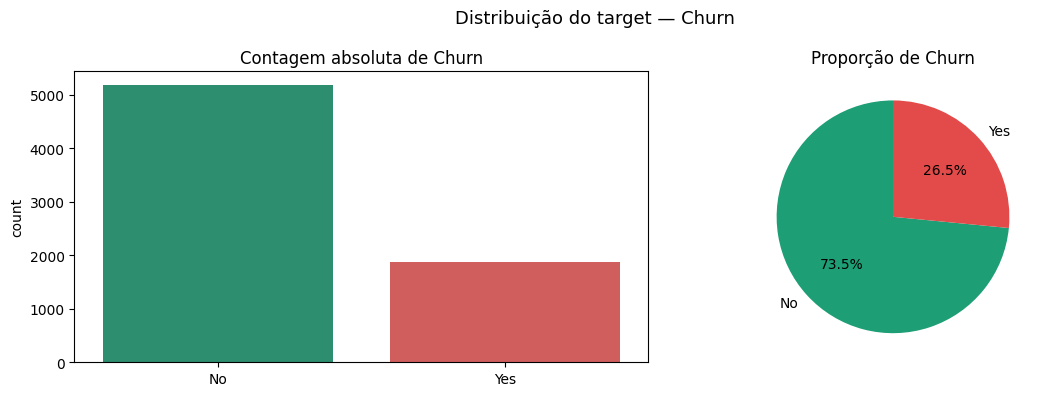

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x='Churn', palette={'Yes': '#E24B4A', 'No': '#1D9E75'}, ax=axes[0])
axes[0].set_title('Contagem absoluta de Churn')
axes[0].set_xlabel('')

churn_pct = df['Churn'].value_counts(normalize=True) * 100
axes[1].pie(churn_pct, labels=churn_pct.index, autopct='%1.1f%%',
            colors=['#1D9E75', '#E24B4A'], startangle=90)
axes[1].set_title('Proporção de Churn')

plt.suptitle('Distribuição do target — Churn', fontsize=13)
plt.tight_layout()
plt.savefig('../data/figures/01_churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [43]:
fig = px.scatter(df, x='tenure', y='MonthlyCharges',
                 color='Churn', opacity=0.5,
                 title='Tenure vs Monthly Charges por Churn',
                 color_discrete_map={'Yes': '#E24B4A', 'No': '#1D9E75'})
fig.show()

## 3. Variáveis numéricas

In [45]:
# TotalCharges como object esconde 11 entradas inválidas
# pd.to_numeric com errors='coerce' converte inválidos para NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(f"Nulos em TotalCharges após conversão: {df['TotalCharges'].isnull().sum()}")
# Esses 11 registros serão tratados no pré-processamento

Nulos em TotalCharges após conversão: 11


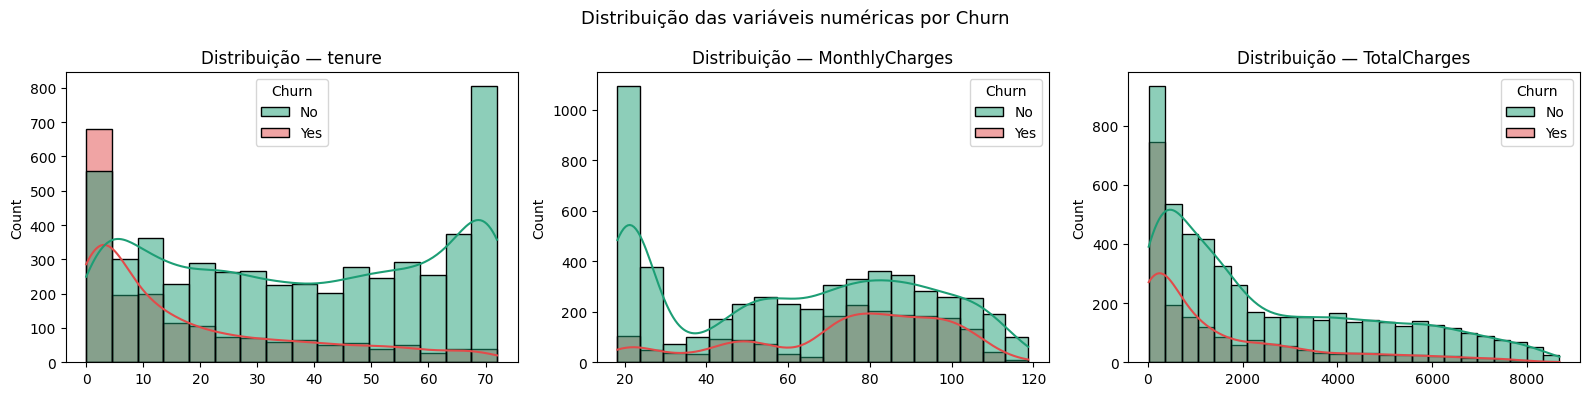

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, ['tenure', 'MonthlyCharges', 'TotalCharges']):
    sns.histplot(data=df, x=col, hue='Churn', kde=True, ax=ax,
                 palette={'Yes': '#E24B4A', 'No': '#1D9E75'})
    ax.set_title(f'Distribuição — {col}')
    ax.set_xlabel('')

plt.suptitle('Distribuição das variáveis numéricas por Churn', fontsize=13)
plt.tight_layout()
plt.savefig('../data/figures/02_numeric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Observações:
# tenure: clientes com churn concentrados nos primeiros meses
# MonthlyCharges: clientes com churn tendem a pagar mais
# TotalCharges: clientes sem churn acumulam mais por permanecerem mais tempo

## 4. Variáveis categóricas

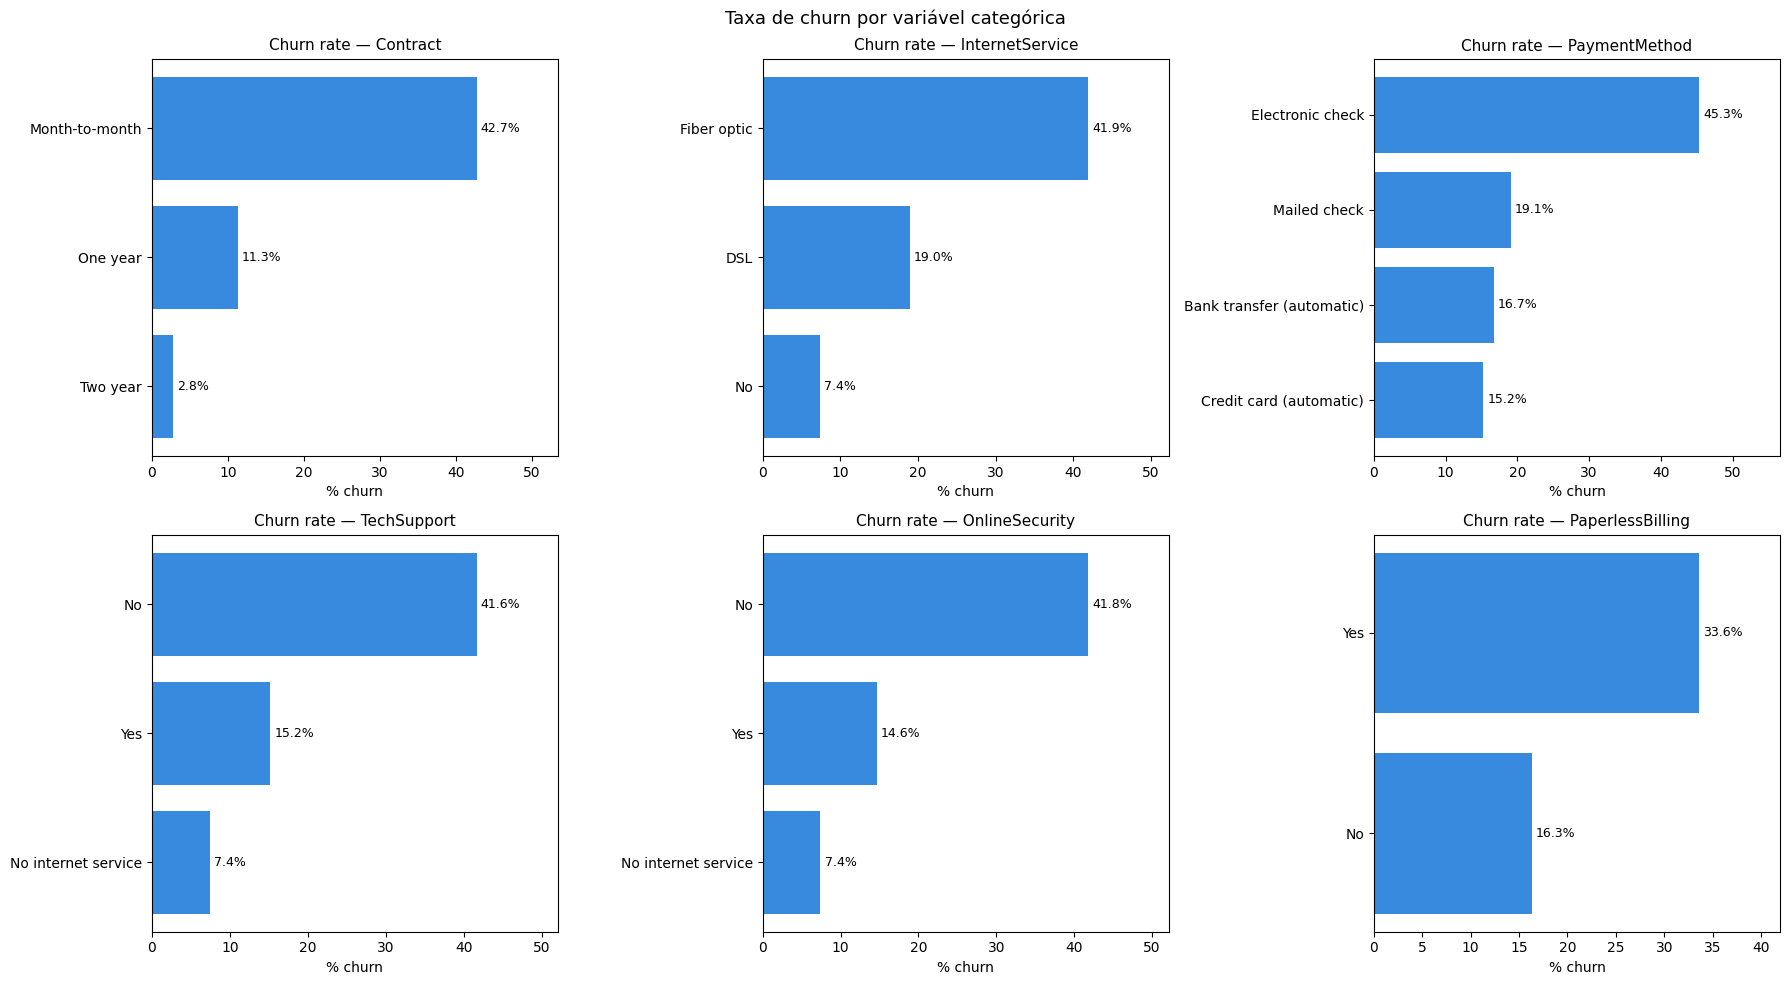

In [47]:
# Foco nas categóricas com maior relevância esperada para churn
cat_cols = ['Contract', 'InternetService', 'PaymentMethod',
            'TechSupport', 'OnlineSecurity', 'PaperlessBilling']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, col in zip(axes.flat, cat_cols):
    rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    rate = rate.sort_values(ascending=True)
    bars = ax.barh(rate.index, rate.values, color='#378ADD')
    ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
    ax.set_title(f'Churn rate — {col}', fontsize=11)
    ax.set_xlabel('% churn')
    ax.set_xlim(0, rate.max() * 1.25)

plt.suptitle('Taxa de churn por variável categórica', fontsize=13)
plt.tight_layout()
plt.savefig('../data/figures/03_churn_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

# Observações:
# Contract: mês a mês tem churn ~42% vs ~3% no contrato de 2 anos
# TechSupport e OnlineSecurity: ausência do serviço associada a churn mais alto
# PaymentMethod: Electronic check tem o maior churn rate

## 5. Correlações

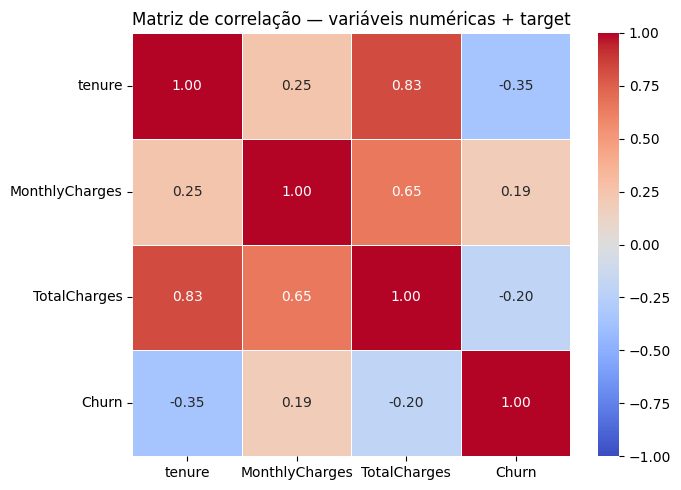

In [ ]:
df_corr = df[['tenure', 'MonthlyCharges', 'TotalCharges']].copy()
df_corr['Churn'] = (df['Churn'] == 'Yes').astype(int)

plt.figure(figsize=(7, 5))
sns.heatmap(df_corr.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de correlação — variáveis numéricas + target')
plt.tight_layout()
plt.savefig('../data/figures/04_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Observações:
# TotalCharges e tenure têm correlação ~0.83, possível multicolinearidade
# No pré-processamento considerar remover TotalCharges ou aplicar PCA
# Churn correlaciona negativamente com tenure: clientes mais antigos cancelam menos

## 6. Principais insights do EDA

- **Desbalanceamento:** 73% No / 27% Yes, precisaremos estratificar quando realizarmos o split e AUC-ROC como métrica principal
- **Contrato:** clientes mês a mês têm churn ~42%, contra ~3% em contratos de 2 anos — feature mais discriminativa
- **Tenure:** clientes que cancelam estão concentrados nos primeiros meses — onboarding pode ser o problema
- **Multicolinearidade:** TotalCharges e tenure têm correlação 0.83 — considerar remover TotalCharges no modelo
- **Serviços adicionais:** ausência de TechSupport e OnlineSecurity associada a maior churn — possível insatisfação com valor percebido
- **Próximo passo:** encoding de categóricas, tratamento dos 11 nulos em TotalCharges e construção do pipeline de pré-processamento